# Starlink Flyovers at REACH Site:

This notebook produces the experimental results used for identifying and visualising SpaceX Starlink satellite flyovers at the Radio Experiment for the Analysis of Cosmic Hydrogen (REACH) site in the Karoo radio reserve, South Africa. 

### Initialising Satellite Data:

Satellite Two-Line Elements (TLEs) are first loaded and filtered to identify the Starlink satellites relevant within the observation window. Satellite trajectories are propagated using the specified observation durection and temporal resolution, while accounting for the REACH site coordinates and horizon profile.

In [1]:
# Imports:
from datetime import datetime
from skyfield.api import load
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Time Array:
ts = load.timescale()
length = 3600*1.5 # in seconds
orbit_duration = np.arange(0, length + 1, 1)
epochs_of_orbit = ts.utc(2025, 6, 15, 12, 25, 8 + orbit_duration)
ref_locations = [["London",51.5,0.128], ["REACH",-30.7,-21.5]]

In [3]:
from astrotrack.preprocess import load_satellite_data

data = load_satellite_data(
    tle_file="../../data/TLE-catalogues/TLEs.txt",
    target_date=datetime(2025, 6, 15, 12, 25, 8),
    obs_len=length,
    traj_res=10,
    obs_lat=-30.71131,
    obs_lon=21.4476236,
    R=1500,
    horizon_data="../../data/horizon-profiles/REACH-Horizon.csv",
    satcon="starlink"
)

Processing satellites:   2%|▏         | 166/7699 [00:22<22:10,  5.66satellite/s]c:\Users\lette\anaconda3\envs\astrotrack\Lib\site-packages\erfa\core.py:4620: RuntimeWarning: invalid value encountered in ld
  p1 = ufunc.ld(bm, p, q, e, em, dlim)
c:\Users\lette\anaconda3\envs\astrotrack\Lib\site-packages\erfa\core.py:19004: RuntimeWarning: invalid value encountered in anp
  c_retval = ufunc.anp(a)
Processing satellites: 100%|██████████| 7699/7699 [30:01<00:00,  4.27satellite/s]  


In [4]:
n_flyovers = len(data)
norads = []
for flyover in data:
    tle_2 = flyover['TLE'][1].split(" ")  # get NORAD from TLE line 2
    norads.append(tle_2[1])  # append NORADs

print(f"Number of Starlink Flyovers at REACH Site: {len(data)}")

Number of Starlink Flyovers at REACH Site: 1952


### Plotting Maximum Elevation Angle Distribution Relative to REACH:

The distribution of $\phi_{\text{max}}$ is plotted to characterise the angular extent of Starlink satellite trajectories relative to the REACH site. This is an especially important consideration for wide-beam radiometers, as instrument-related systematics are dominated by antenna chromaticity. Chromaticity arises because the antenna beam pattern is inherently frequency-dependent whereby the gain varies with frequency as well as sky position. Hence, satellite flyovers achieving $\phi \rightarrow 90^{\circ}$ are of particular interest as they pass close to zenith, although their relevance ultimately depends on their potential emission frequency.

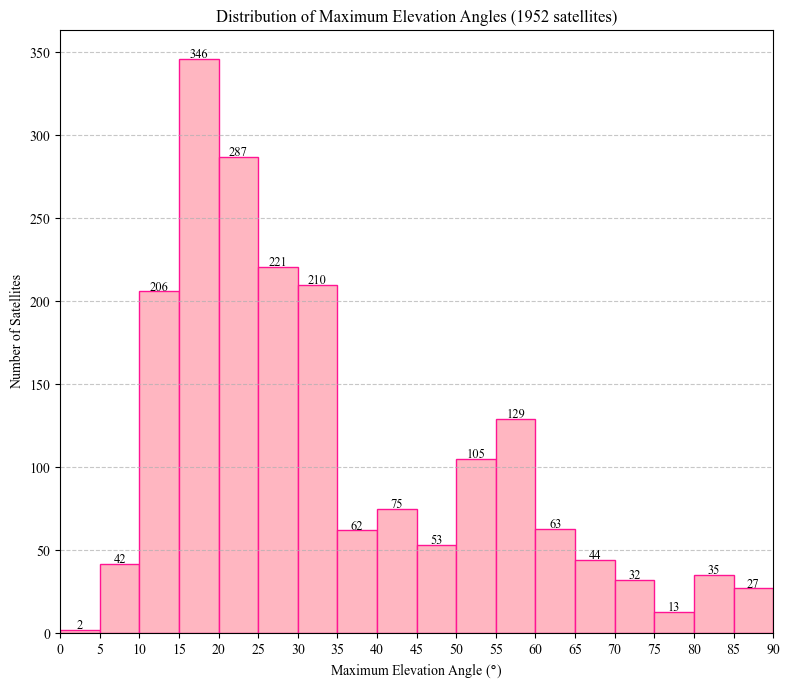

In [7]:
from astrotrack.satcon_properties import plot_max_elevation_histogram

plot_max_elevation_histogram(
    data,
    font_family="Times New Roman",
    figsize=(8, 7),
    color="lightpink",
    edgecolor="deeppink"
)